# 02 - Feature Engineering

Build the **14-feature** daily input block for Mohamed's model:

  1-6   Open, High, Low, Close, Volume, MACD       (price)
  7-10  finbert_{positive,negative,neutral,confidence}  (sentiment)
  11    headline_count
  12    no_news_flag
  13    net_sentiment_ma3
  14    net_sentiment_ma7

The FinBERT cache is built by `src/_run_sentiment_cache.py` (or by calling
`ensure_sentiment_cache()` here). This notebook visualises the cached
features only - it does not re-run the model.


In [1]:
import sys, os
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid'); plt.rcParams['figure.dpi'] = 110

from src import data_loader as dl
from src.data_loader import PLOTS_DIR, ALL_FEATURES, PRICE_FEATURES, SENTIMENT_FEATURES
from src.sentiment_features import ensure_sentiment_cache, DAILY_PARQUET, PER_HEADLINE_PARQUET

PLOTS_DIR.mkdir(parents=True, exist_ok=True)


## 1. Build (or load) the FinBERT cache

If the cache is missing this step will download the model and score all
~45k headlines on CPU. On a typical laptop this takes 15-25 minutes.


In [2]:
if not PER_HEADLINE_PARQUET.exists() or not DAILY_PARQUET.exists():
    per, daily, used = ensure_sentiment_cache(force=False)
    print('Built cache. Model used:', used)
else:
    print('Cache already exists - skipping FinBERT inference.')
print('per-headline:', PER_HEADLINE_PARQUET, '(exists:', PER_HEADLINE_PARQUET.exists(), ')')
print('daily       :', DAILY_PARQUET,        '(exists:', DAILY_PARQUET.exists(), ')')


Cache already exists - skipping FinBERT inference.
per-headline: C:\Users\alsha\Desktop\Mohamed\results\cache\headline_finbert_scores.parquet (exists: True )
daily       : C:\Users\alsha\Desktop\Mohamed\results\cache\daily_sentiment_features.parquet (exists: True )


In [3]:
daily = pd.read_parquet(DAILY_PARQUET)
daily['Date'] = pd.to_datetime(daily['Date'])
print('daily rows :', len(daily))
print('date range :', daily['Date'].min().date(), '->', daily['Date'].max().date())
print('columns    :', list(daily.columns))
daily.head()


daily rows : 6259
date range : 2000-02-15 -> 2024-12-31
columns    : ['Date', 'finbert_positive', 'finbert_negative', 'finbert_neutral', 'finbert_confidence', 'headline_count', 'no_news_flag', 'net_sentiment', 'net_sentiment_ma3', 'net_sentiment_ma7']


,Date,finbert_positive,finbert_negative,finbert_neutral,finbert_confidence,headline_count,no_news_flag,net_sentiment,net_sentiment_ma3,net_sentiment_ma7
0,2000-02-15,0.171557,0.201554,0.626889,0.810891,220,0,-0.029996,-0.029996,-0.029996
1,2000-02-16,0.058507,0.191222,0.750272,0.896009,5,0,-0.132715,-0.081356,-0.081356
2,2000-02-17,0.134201,0.289253,0.576546,0.810692,5,0,-0.155052,-0.105921,-0.105921
3,2000-02-18,0.067134,0.365232,0.567634,0.857845,5,0,-0.298099,-0.195288,-0.153965
4,2000-02-22,0.144342,0.259579,0.596078,0.814480,20,0,-0.115237,-0.189463,-0.146220


## 2. Sentiment-score distributions across the corpus

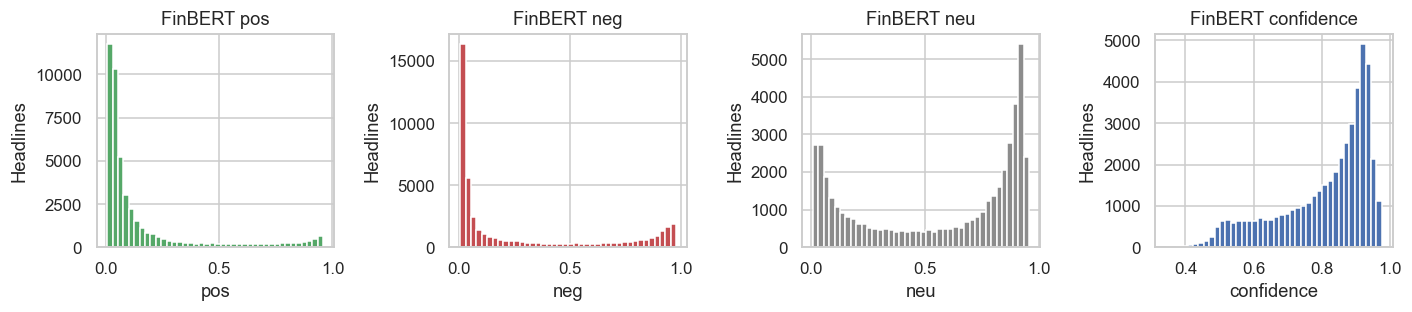

In [4]:
per_headline = pd.read_parquet(PER_HEADLINE_PARQUET)
fig, axes = plt.subplots(1, 4, figsize=(13, 3))
for ax, col, color in zip(axes, ['pos', 'neg', 'neu', 'confidence'], ['C2', 'C3', 'C7', 'C0']):
    ax.hist(per_headline[col], bins=40, color=color, edgecolor='white')
    ax.set_title(f'FinBERT {col}'); ax.set_xlabel(col); ax.set_ylabel('Headlines')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '02_finbert_score_distributions.png', dpi=150)
plt.show()


## 3. Daily features over time

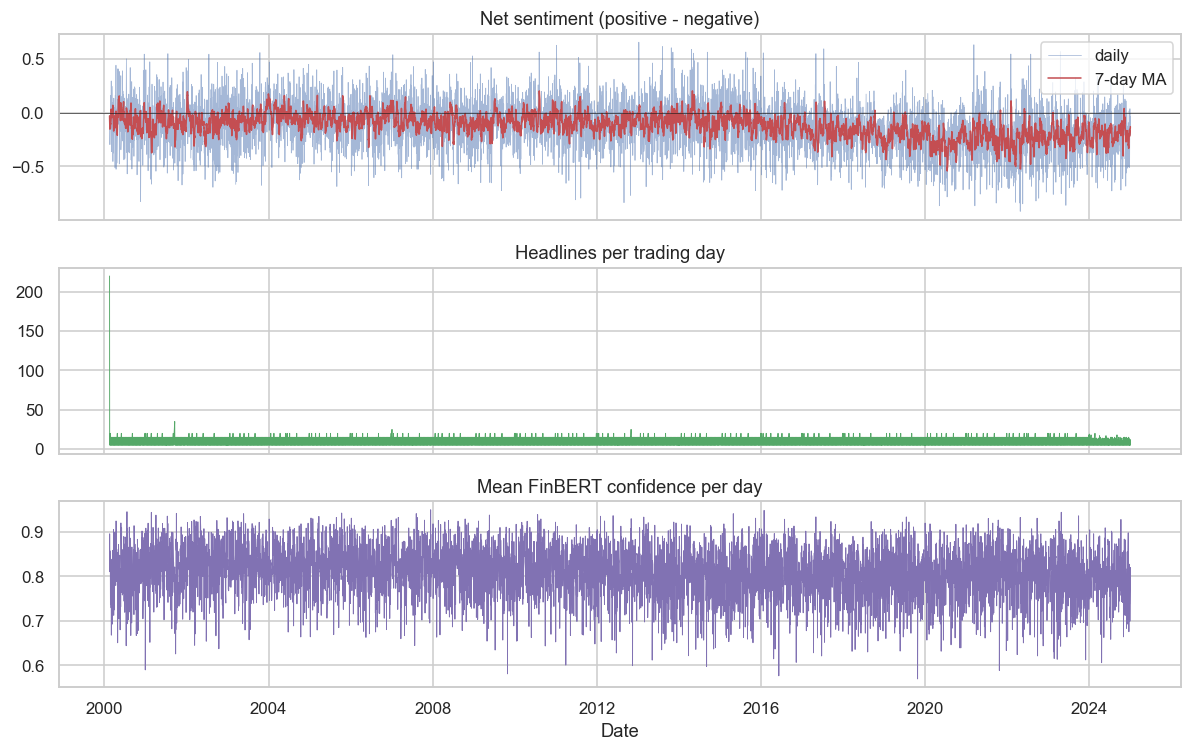

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
axes[0].plot(daily['Date'], daily['net_sentiment'], color='C0', lw=0.5, alpha=0.5, label='daily')
axes[0].plot(daily['Date'], daily['net_sentiment_ma7'], color='C3', lw=1, label='7-day MA')
axes[0].axhline(0, color='k', lw=0.4)
axes[0].set_title('Net sentiment (positive - negative)')
axes[0].legend()

axes[1].plot(daily['Date'], daily['headline_count'], color='C2', lw=0.6)
axes[1].set_title('Headlines per trading day')

axes[2].plot(daily['Date'], daily['finbert_confidence'], color='C4', lw=0.6)
axes[2].set_title('Mean FinBERT confidence per day')
axes[2].set_xlabel('Date')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '02_daily_sentiment_timeseries.png', dpi=150)
plt.show()


## 4. Assemble the merged 14-feature DataFrame and run a correlation heatmap

In [6]:
ds = dl.assemble_dataset(use_sentiment=True, window=20)
print('train X :', ds['X_train'].shape)
print('val   X :', ds['X_val'].shape)
print('test  X :', ds['X_test'].shape)
print('feature names:', ds['feature_names'])
df = ds['df']
df.head()


train X : (4353, 20, 14)
val   X : (943, 20, 14)
test  X : (939, 20, 14)
feature names: ['Open', 'High', 'Low', 'Close', 'Volume', 'MACD', 'finbert_positive', 'finbert_negative', 'finbert_neutral', 'finbert_confidence', 'headline_count', 'no_news_flag', 'net_sentiment_ma3', 'net_sentiment_ma7']


,Date,Open,High,Low,Close,Volume,MACD,MACD_Signal,MACD_Hist,target_t1,...,target_t5,finbert_positive,finbert_negative,finbert_neutral,finbert_confidence,headline_count,no_news_flag,net_sentiment,net_sentiment_ma3,net_sentiment_ma7
0,2000-02-15,98.93750,100.6250,95.8750,100.46875,30572800,2.264615,1.507757,0.756859,-0.004666,...,0.037636,0.171557,0.201554,0.626889,0.810891,220,0,-0.029996,-0.029996,-0.029996
1,2000-02-16,99.90625,101.6875,99.3125,100.00000,25310600,2.253420,1.656889,0.596531,0.021250,...,0.065000,0.058507,0.191222,0.750272,0.896009,5,0,-0.132715,-0.081356,-0.081356
2,2000-02-17,101.18750,103.2500,99.6250,102.12500,30080200,2.388484,1.803208,0.585276,-0.036108,...,0.018972,0.134201,0.289253,0.576546,0.810692,5,0,-0.155052,-0.105921,-0.105921
3,2000-02-18,102.62500,103.0000,98.4375,98.43750,25271200,2.172925,1.877151,0.295773,0.003175,...,0.056508,0.067134,0.365232,0.567634,0.857845,5,0,-0.298099,-0.195288,-0.153965
4,2000-02-22,99.00000,99.9375,96.2500,98.75000,37226200,2.004205,1.902562,0.101643,0.055696,...,0.081013,0.144342,0.259579,0.596078,0.814480,20,0,-0.115237,-0.189463,-0.146220


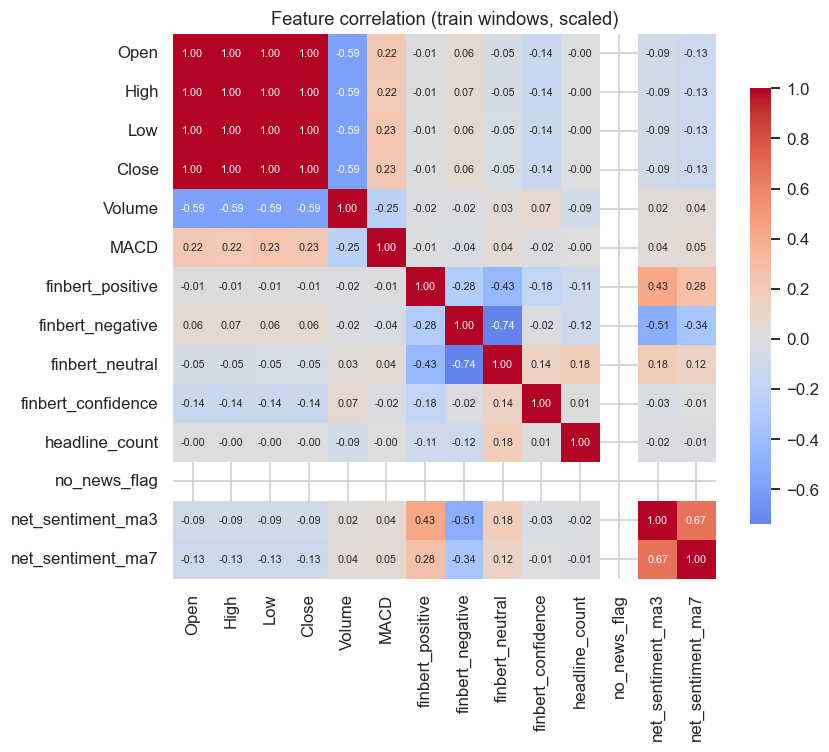

In [7]:
# Correlation among the 14 features ON THE TRAIN SLICE ONLY
train_idx = ds['split'].train
X_long = pd.DataFrame(
    np.concatenate([ds['X_train'].reshape(-1, ds['X_train'].shape[-1])]),
    columns=ds['feature_names'],
)
corr = X_long.corr()

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            cbar_kws={'shrink': 0.8}, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature correlation (train windows, scaled)')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '02_feature_correlation_heatmap.png', dpi=150)
plt.show()


## 5. Sanity check: returns target distribution

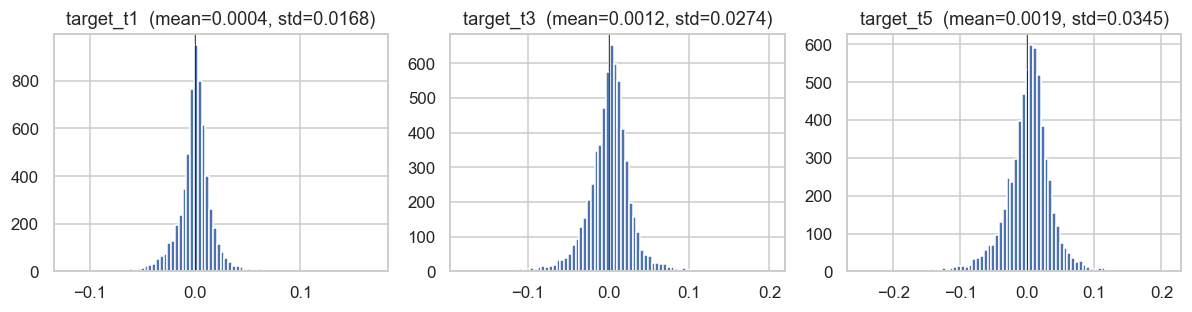

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for ax, col in zip(axes, ds['target_cols']):
    vals = df[col].dropna()
    ax.hist(vals, bins=80, color='C0', edgecolor='white')
    ax.axvline(0, color='k', lw=0.5)
    ax.set_title(f'{col}  (mean={vals.mean():.4f}, std={vals.std():.4f})')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '02_target_distributions.png', dpi=150)
plt.show()


## 6. Summary

- 14-feature daily block successfully assembled for the full date range.
- Sentiment is mostly neutral with a long tail of positive/negative scores -
  consistent with how FinBERT scores generic news.
- The strongest correlations live among the OHLC columns (as expected) and
  among the sentiment block (positive vs. negative are anti-correlated).
- All targets are roughly mean-zero with a heavier tail at t+5.

These figures land in `results/plots/02_*.png`.
